In [1]:
import pandas as pd
import sqlite3

In [2]:
conn = sqlite3.connect("../data/checking-logs.sqlite")
schema = pd.read_sql("PRAGMA table_info(checker);", conn)

print(schema)

   cid       name       type  notnull dflt_value  pk
0    0      index    INTEGER        0       None   0
1    1     status       TEXT        0       None   0
2    2    success    INTEGER        0       None   0
3    3  timestamp  TIMESTAMP        0       None   0
4    4  numTrials    INTEGER        0       None   0
5    5    labname       TEXT        0       None   0
6    6        uid       TEXT        0       None   0


In [3]:
df = pd.read_sql_query(
    '''
    SELECT timestamp AS commits
    FROM checker
    WHERE uid LIKE 'user_%'
    ''',
    conn,
    parse_dates=['commits'],
)

df['weekday'] = df['commits'].apply(lambda x: 'weekend' if x.dayofweek > 4 else 'working_day')
df['hour'] = df['commits'].dt.hour
df['date'] = df['commits'].dt.date

daily_commits = df.groupby(['date', 'weekday', 'hour']).size().reset_index(name='count')
average_commits = daily_commits.groupby(['weekday', 'hour'])['count'].mean().unstack().T
average_commits[average_commits.index == 17]

weekday,weekend,working_day
hour,,
17,7.142857,16.0


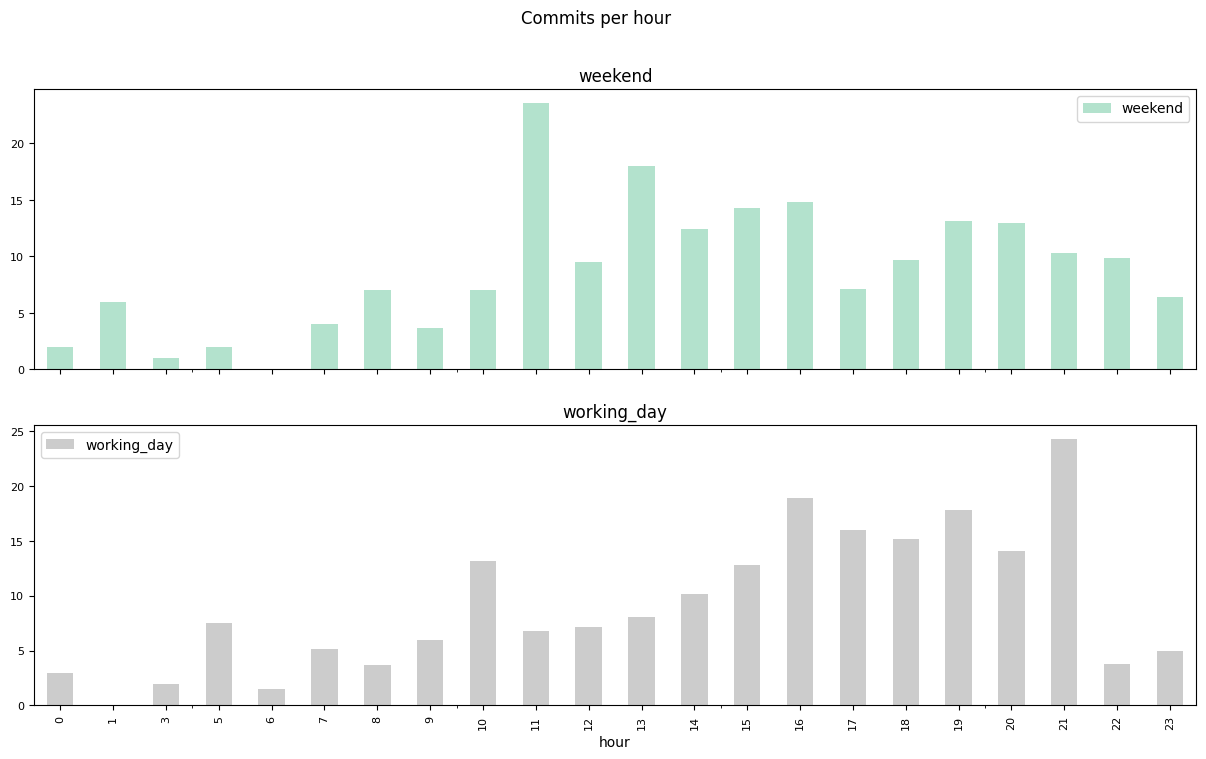

In [4]:
ax = average_commits.plot(kind='bar',
                          subplots=True,
                          fontsize=8,
                          figsize=(15, 8),
                          title='Commits per hour',
                          cmap='Pastel2',
)

- Is the dynamic different on working days and weekends? 21 and 11.

In [5]:
conn.close()